# PatchCore Experiment Notebook

In [4]:
import importlib

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from src import config
from src.backbone import get_backbone
from datasets.data import MyData
from src.models import PatchCore
from utils.auc import get_image_auc #get_pixel_auc

print("class:", config.CLASS_NAME)
print("k:", config.K)
print("train limit:", config.TRAIN_LIMIT)
print("test limit:", config.TEST_LIMIT)
print("test limit per class:", config.TEST_LIMIT_PER_CLASS)

class: tile
k: 10
train limit: 50
test limit: 30
test limit per class: 3


## SET Device

In [5]:

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(device)

mps


## Load Dataset

- datasets/data.py

In [6]:
train_data = MyData(
    config.CLASS_NAME,
    phase="train",
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    limit=config.TRAIN_LIMIT,
    dname = "Visa"
)

test_data = MyData(
    config.CLASS_NAME,
    phase="test",
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    limit=config.TEST_LIMIT,
    limit_per_class=config.TEST_LIMIT_PER_CLASS,
    dname = "Visa"
)

print("train images:", len(train_data))
print("test images:", len(test_data))
print("test classes:", test_data.get_classes())

class_counts = {name: 0 for name in test_data.get_classes()}
for _, label in test_data:
    class_counts[test_data.get_classes()[label]] += 1
print("test class counts:", class_counts)
test_data[0]

FileNotFoundError: [Errno 2] No such file or directory: 'data/Visa/tile/train'

## Fit PatchCore

In [ ]:
backbone = get_backbone()
patchcore = PatchCore(backbone, k=config.K, device=device)

patchcore.fit(train_data)

print("memory bank shape:", tuple(patchcore.memory_bank.shape))

memory bank shape: (10, 384)


## Visualize One Result

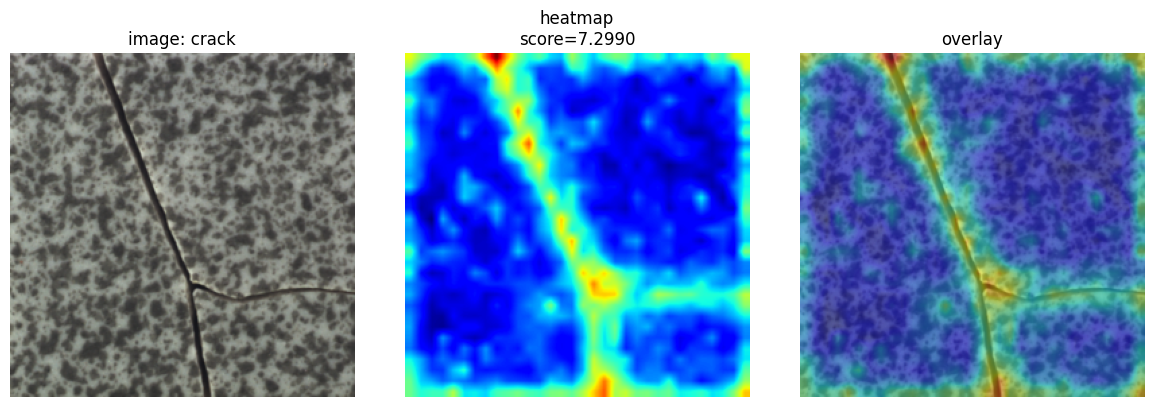

(7.29897403717041, 'crack')

In [ ]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def denormalize(img):
    img = img.detach().cpu() * IMAGENET_STD + IMAGENET_MEAN
    return img.clamp(0, 1)


def show_result(index=0):
    img, label = test_data[index]
    score, heatmap = patchcore.predict(img)

    image = denormalize(img).permute(1, 2, 0).numpy()
    heatmap = heatmap.detach().cpu()
    heatmap = F.interpolate(
        heatmap.unsqueeze(0).unsqueeze(0),
        size=image.shape[:2],
        mode="bilinear",
        align_corners=False,
    ).squeeze()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    heatmap_np = heatmap.numpy()
    label_name = test_data.get_classes()[label]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image)
    axes[0].set_title(f"image: {label_name}")
    axes[0].axis("off")

    axes[1].imshow(heatmap_np, cmap="jet")
    axes[1].set_title(f"heatmap\nscore={score.item():.4f}")
    axes[1].axis("off")

    axes[2].imshow(image)
    axes[2].imshow(heatmap_np, cmap="jet", alpha=0.45)
    axes[2].set_title("overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return score.item(), label_name


show_result(config.TEST_INDEX)

## Compare Test Scores

In [ ]:
scores = []

for i in range(len(test_data)):
    img, label = test_data[i]
    score, _ = patchcore.predict(img)
    scores.append((i, score.item(), test_data.get_classes()[label]))

scores = sorted(scores, key=lambda x: x[1], reverse=True)
scores[:10]

[(0, 7.29897403717041, 'crack'),
 (2, 7.010420322418213, 'crack'),
 (11, 6.525341987609863, 'gray_stroke'),
 (1, 6.46942663192749, 'crack'),
 (6, 6.37231969833374, 'good'),
 (3, 6.129368782043457, 'glue_strip'),
 (14, 5.947980880737305, 'oil'),
 (5, 5.932026386260986, 'glue_strip'),
 (12, 5.898491859436035, 'oil'),
 (10, 5.8826680183410645, 'gray_stroke')]

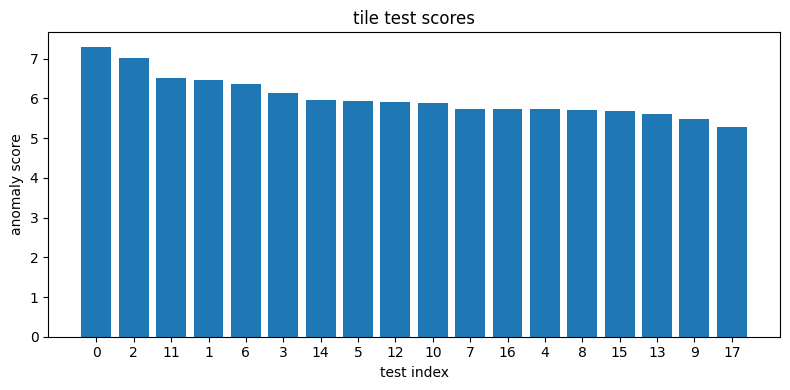

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar([str(i) for i, _, _ in scores], [score for _, score, _ in scores])
plt.xlabel("test index")
plt.ylabel("anomaly score")
plt.title(f"{config.CLASS_NAME} test scores")
plt.tight_layout()
plt.show()

## Inspect Top Scored Images

index: 0 score: 7.299 label: crack


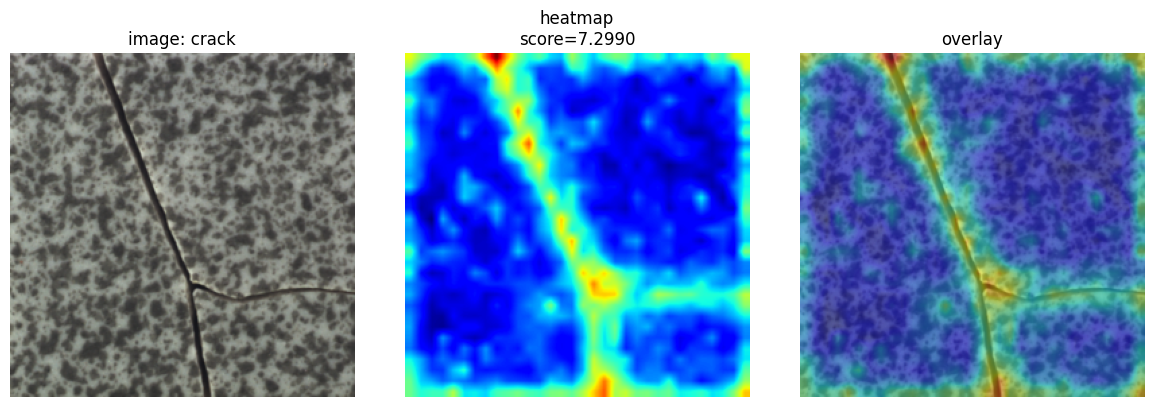

index: 2 score: 7.0104 label: crack


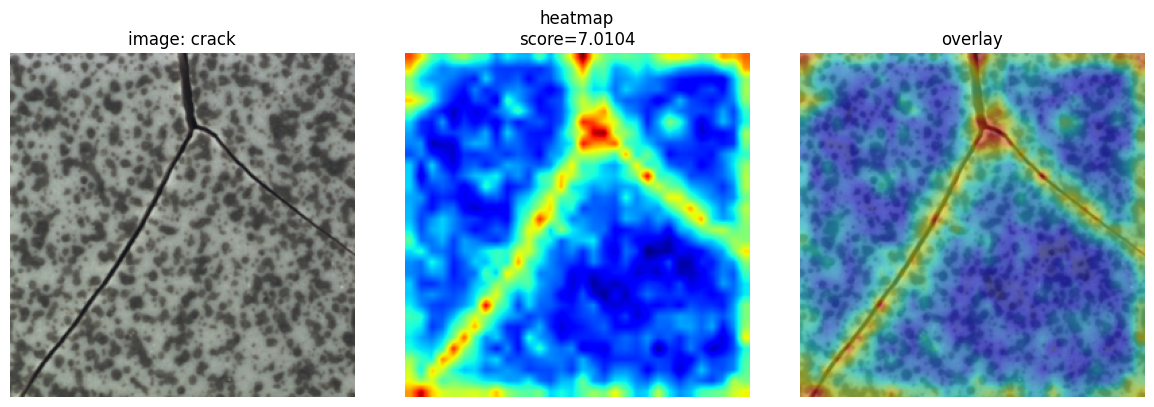

index: 11 score: 6.5253 label: gray_stroke


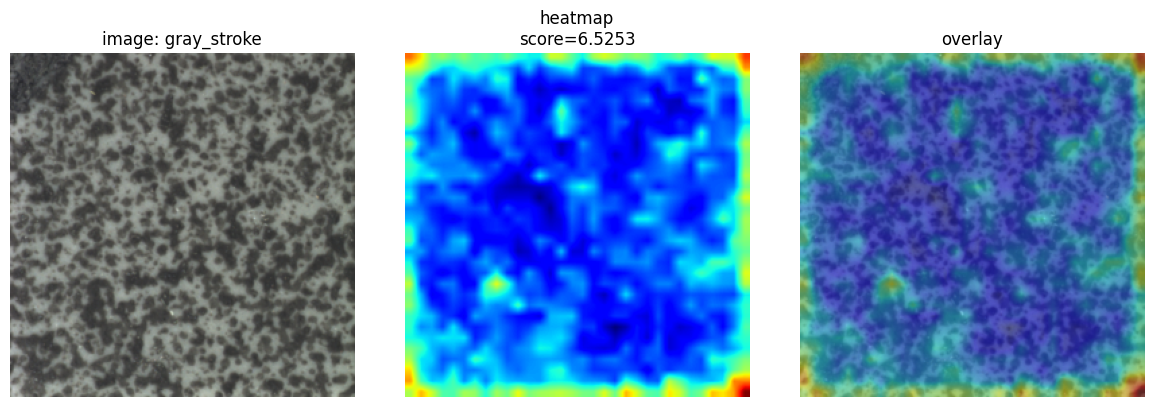

In [ ]:
for index, score, label_name in scores[:3]:
    print("index:", index, "score:", round(score, 4), "label:", label_name)
    show_result(index)

In [ ]:
image_auc = get_image_auc(test_data, patchcore)
image_auc

np.float64(0.9777777777777777)

In [ ]:
# import csv
# import os

# file_path = "results.csv"
# file_exists = os.path.isfile(file_path)

# with open(file_path, 'a', newline="") as f:
#     writer = csv.writer(f)

#     if not file_exists:
#         writer.writerow(["category","train_limit","k","auc"])
#     writer.writerow([config.CLASS_NAME, config.TRAIN_LIMIT, config.K, image_auc ])
        

- pixel단위 auc는 ground_truth 사용 필요. dataloader 추후 수정

In [ ]:
# pixel_auc = get_pixel_auc(test_data, patchcore)
# pixel_auc

In [ ]:
# import pandas as pd

# data = pd.read_csv("results.csv")
# data

In [ ]:
# import pandas as pd
# df = pd.read_csv("results.csv")
# df = df.sort_values(by='auc',ascending = False).reset_index(drop=True)
# df.to_csv("results.csv")

In [ ]:
# import pandas as pd
# pd.read_csv("results.csv")